In [1]:
import pandas as pd
import glob

cols = ['open_time','open','high','low','close','volume',
        'close_time','quote_volume','trades','taker_buy_base',
        'taker_buy_quote','ignore']

BASE = '/home/onyxia/work/binance-public-data/python/data/spot/monthly/klines'

def load_symbol(symbol):
    files = sorted(glob.glob(f'{BASE}/{symbol}/1h/**/*.zip', recursive=True))
    print(f"{symbol}: {len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f, names=cols) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    t = pd.to_numeric(df['open_time'], errors='coerce')
    df = df[t.notna()]
    t = t[t.notna()]
    t = (t / 1000).where(t > 1e14, t)
    df['open_time'] = pd.to_datetime(t, unit='ms')

    df = df.set_index('open_time').sort_index()
    return df['close'].astype(float).rename(symbol)

btc = load_symbol('BTCUSDT')
eth = load_symbol('ETHUSDT')
sol = load_symbol('SOLUSDT')

prices = pd.concat([btc, eth, sol], axis=1).dropna().reset_index()
print(prices.shape)

BTCUSDT: 6 fichiers trouvés
ETHUSDT: 6 fichiers trouvés
SOLUSDT: 6 fichiers trouvés
(4344, 4)


In [2]:
prices.head(20)

,open_time,BTCUSDT,ETHUSDT,SOLUSDT
0,2025-01-01 00:00:00,94401.14,3363.70,192.54
1,2025-01-01 01:00:00,93607.74,3346.54,190.70
2,2025-01-01 02:00:00,94098.91,3362.61,191.59
3,2025-01-01 03:00:00,93838.04,3355.20,190.43
4,2025-01-01 04:00:00,93553.91,3341.14,189.47
5,2025-01-01 05:00:00,93792.02,3345.41,190.15
6,2025-01-01 06:00:00,93757.58,3346.60,190.30
7,2025-01-01 07:00:00,93684.10,3347.12,190.06
8,2025-01-01 08:00:00,93428.46,3337.01,189.40
9,2025-01-01 09:00:00,93413.06,3334.64,189.18


In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

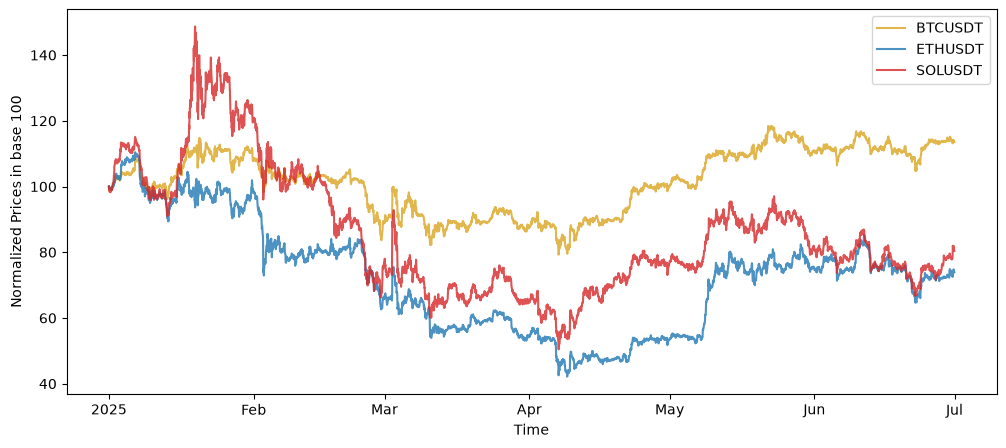

In [4]:
locator = mdates.AutoDateLocator()


fig,ax=plt.subplots(figsize=(12,5))
colors={
    'BTCUSDT':'goldenrod',
    'ETHUSDT':'tab:blue',
    'SOLUSDT':'tab:red'}
for col,color in colors.items():
    ax.plot(prices['open_time'],
    prices[col]/(prices[col].iloc[0])*100, #To be on the same scale, we compare their evolution, not their level
    color=color,
    label=col,
    alpha=0.8)
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Prices in base 100")
ax.legend()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.show()
    




In [6]:
import numpy as np

In [9]:
prices["log_BTC"]=np.log(prices['BTCUSDT'])
prices["log_ETH"]=np.log(prices['ETHUSDT'])
prices["log_SOL"]=np.log(prices['SOLUSDT'])

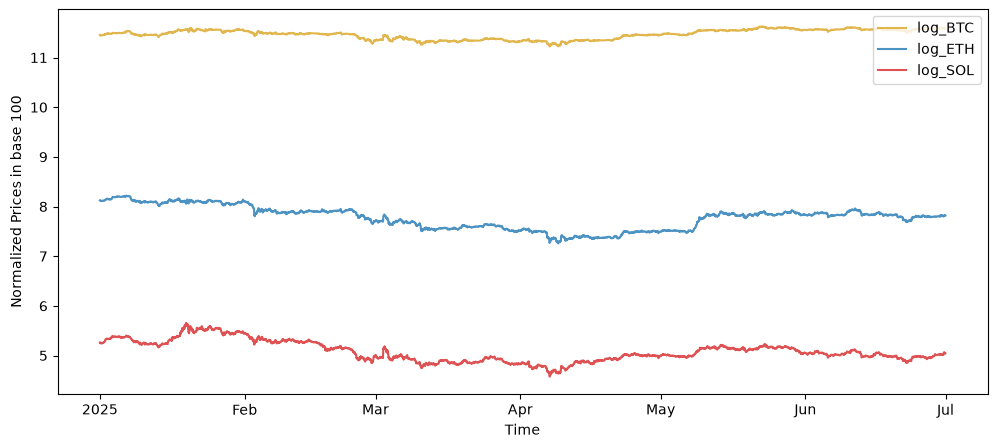

In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
colors={
    'log_BTC':'goldenrod',
    'log_ETH':'tab:blue',
    'log_SOL':'tab:red'}
for col,color in colors.items():
    ax.plot(prices['open_time'],
    prices[col], #To be on the same scale, we compare their evolution, not their level
    color=color,
    label=col,
    alpha=0.8)
ax.set_xlabel("Time")
ax.set_ylabel("Log Prices")
ax.legend()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.show()
    




In [17]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

log_symbols=['log_BTC','log_ETH','log_SOL']
def adf_manuel(log, p):
    dlog = log.diff()
    X = pd.DataFrame(index=log.index)
    X['niveau_lag1'] = log.shift(1)
    for i in range(1, p + 1):
        X[f'dlog_lag_{i}'] = dlog.shift(i)
    X['const'] = 1.0
    reg = pd.concat([dlog.rename('dlog'), X], axis=1).dropna()
    res = sm.OLS(reg['dlog'], reg.drop(columns='dlog')).fit()
    return res.tvalues['niveau_lag1'], res.aic, len(reg)

for ls in log_symbols:
    aics = {}
    log = prices[ls]
    print(f"\n=== {ls} ===")
    for p in range(1, 16):
        t, aic, n = adf_manuel(log, p)
        aics[p] = aic
        ref = adfuller(log.dropna(), maxlag=p, autolag=None, regression='c')[0]
        print(f"p={p:2d}  t={t:7.3f}  ref={ref:7.3f}  écart={abs(t-ref):.2e} AIC={aic:.2e} n={n}")
    p_opt = min(aics, key=aics.get)
    print(f'the number of diffs for {ls} that minimizes AIC is {p_opt}')


=== log_BTC ===
p= 1  t= -1.588  ref= -1.588  écart=0.00e+00 AIC=-3.32e+04 n=4342
p= 2  t= -1.602  ref= -1.602  écart=0.00e+00 AIC=-3.32e+04 n=4341
p= 3  t= -1.542  ref= -1.542  écart=0.00e+00 AIC=-3.32e+04 n=4340
p= 4  t= -1.597  ref= -1.597  écart=0.00e+00 AIC=-3.32e+04 n=4339
p= 5  t= -1.613  ref= -1.613  écart=0.00e+00 AIC=-3.32e+04 n=4338
p= 6  t= -1.590  ref= -1.590  écart=0.00e+00 AIC=-3.32e+04 n=4337
p= 7  t= -1.562  ref= -1.562  écart=0.00e+00 AIC=-3.32e+04 n=4336
p= 8  t= -1.606  ref= -1.606  écart=2.22e-16 AIC=-3.32e+04 n=4335
p= 9  t= -1.560  ref= -1.560  écart=0.00e+00 AIC=-3.32e+04 n=4334
p=10  t= -1.601  ref= -1.601  écart=0.00e+00 AIC=-3.32e+04 n=4333
p=11  t= -1.571  ref= -1.571  écart=0.00e+00 AIC=-3.31e+04 n=4332
p=12  t= -1.588  ref= -1.588  écart=0.00e+00 AIC=-3.31e+04 n=4331
p=13  t= -1.564  ref= -1.564  écart=0.00e+00 AIC=-3.31e+04 n=4330
p=14  t= -1.519  ref= -1.519  écart=0.00e+00 AIC=-3.31e+04 n=4329
p=15  t= -1.477  ref= -1.477  écart=0.00e+00 AIC=-3.31e+04 